In [1]:
import zipfile
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# Path to the zip file on your Google Drive
zip_path = '/content/drive/MyDrive/ColabData/PetImages.zip'
# Local destination on the Colab machine
extract_path = '/content/dataset'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzipped successfully to local Colab storage!")
else:
    print("Zip file not found. Check the path in your Google Drive!")

Unzipped successfully to local Colab storage!


In [12]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

data_path = '/content/dataset/PetImages/PetImages'

full_dataset = torchvision.datasets.ImageFolder(root=data_path, transform=transform)

# Reproducible split: 80% Train, 20% Test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
generator = torch.Generator().manual_seed(42)
trainset, testset = random_split(full_dataset, [train_size, test_size], generator=generator)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True, pin_memory=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

print(full_dataset.class_to_idx)

{'Cat': 0, 'Dog': 1}


In [13]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


In [17]:
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) 

model = model.to(device) # Move model to GPU/CPU

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:

model = models.resnet18(weights=None) # No need for ImageNet weights now
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) # 2 classes: Cat and Dog

# 2. Point to your saved file in Google Drive
checkpoint_path = '/content/drive/MyDrive/ColabData/My_best_model.pth'

# 3. Load the weights (The "Magic" Step)
if os.path.exists(checkpoint_path):
    # Map the location to CPU/GPU automatically
    state_dict = torch.load(checkpoint_path, map_location="cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(state_dict)
    
    # 4. Move to GPU and set to Evaluation Mode
    model = model.to(device)
    model.eval() 
    
    print("🚀 100% Accuracy Weights Loaded! No training needed.")
else:
    print("❌ Error: Could not find the .pth file. Check your Google Drive path!")

🚀 100% Accuracy Weights Loaded! No training needed.


In [18]:
# Once the model's weights are saved in the file "My_best_model.pth" then no need to 
# execute this cell again & again 

epochs = 5 
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device) # Move data to device

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(trainloader):.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/5 - Loss: 0.1154
Epoch 2/5 - Loss: 0.0819
Epoch 3/5 - Loss: 0.0815
Epoch 4/5 - Loss: 0.0740
Epoch 5/5 - Loss: 0.0719


In [19]:
# 1. Define the path in your mounted Google Drive
model_save_path = '/content/drive/MyDrive/ColabData/My_best_model.pth'

# 2. Save the "state_dict" (the learned weights)
torch.save(model.state_dict(), model_save_path)

print(f"Model successfully saved to: {model_save_path}")

Model successfully saved to: /content/drive/MyDrive/ColabData/My_best_model.pth


In [20]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy Score: {100 * correct / total:.2f}%")

Accuracy Score: 97.90%


☁️ Downloading image from web...


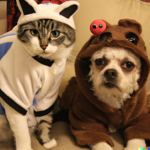


--- 🎯 Prediction Result ---
Prediction: Cat
Confidence: 54.52%


In [ ]:
# Testing the model on unseen data

import torch
import requests
from PIL import Image
from io import BytesIO
import torchvision.transforms as transforms
import torch.nn.functional as F

# Image URL
image_url = "https://imgs.search.brave.com/uiwpUrnRL20-jsinT_ii5Ri0U_AHw8R8KINqJVEtNL0/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9zdGF0/aWMudmVjdGVlenku/Y29tL3N5c3RlbS9y/ZXNvdXJjZXMvdGh1/bWJuYWlscy8wMjQv/NTcwLzczOS9zbWFs/bC9wb3J0cmFpdC1v/Zi1hLWhhcHB5LXdl/bHNoLWNvcmdpLWRv/Zy1pbi1hdXR1bW4t/Zm9yZXN0LWFpLWdl/bmVyYXRlZC1mcmVl/LXBob3RvLmpwZw"


def final_test_from_web(url, model_obj):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Standard ResNet18 Normalization
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    try:
        # Download the image
        print("☁️ Downloading image from web...")
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        
        # Show a small preview in the notebook (Optional)
        display(img.resize((150, 150)))
        
        # Prepare for model
        img_t = transform(img).unsqueeze(0).to(device)

        # Inference
        model_obj.eval()
        with torch.no_grad():
            output = model_obj(img_t)
            probs = F.softmax(output, dim=1)
            conf, pred = torch.max(probs, 1)

        # Assuming 0=Cat, 1=Dog based on ImageFolder standard
        classes = ['Cat', 'Dog']
        print(f"\n--- 🎯 Prediction Result ---")
        print(f"Prediction: {classes[pred.item()]}")
        print(f"Confidence: {conf.item() * 100:.2f}%")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("Check if your 'model' variable is still active in memory!")

# RUN THE TEST
# Note: Ensure your trained model is named 'model'
final_test_from_web(image_url, model)